In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("nfip_quarterly_adjusted.csv")
df["quarter_dt"] = pd.PeriodIndex(df["quarter"], freq="Q").to_timestamp()
df = df.set_index("quarter_dt")

# Excluimos los últimos 2 trimestres incompletos (rezago de reporte FEMA)
df = df.iloc[:-2]

# Dos ventanas con propósitos distintos: histórico completo para EVT,
# ventana desde el quiebre estructural (2004, confirmado con ruptures/Pelt)
# para SARIMA de frecuencia y severidad.
freq_full = np.log(df["n_claims"])
freq_recent = np.log(df["n_claims"].loc["2004":])

print(f"Ventana completa (EVT): {len(freq_full)} trimestres ({freq_full.index.min().year}-{freq_full.index.max().year})")
print(f"Ventana reciente (SARIMA, desde quiebre 2004): {len(freq_recent)} trimestres ({freq_recent.index.min().year}-{freq_recent.index.max().year})")

Ventana completa (EVT): 192 trimestres (1978-2025)
Ventana reciente (SARIMA, desde quiebre 2004): 88 trimestres (2004-2025)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.stats import genpareto

In [3]:
df = pd.read_csv("nfip_quarterly_adjusted.csv")
df["quarter_dt"] = pd.PeriodIndex(df["quarter"], freq="Q").to_timestamp()
df = df.set_index("quarter_dt")

# Excluimos los últimos 2 trimestres incompletos (rezago de reporte FEMA)
df = df.iloc[:-2]

# Ventana "reciente" para SARIMA, basada en el quiebre estructural
# detectado en 2004 (no un corte arbitrario de "últimos 15 años")
freq_recent = np.log(df["n_claims"].loc["2004":])
sev_recent = np.log(df["avg_severity_real"].loc["2004":])

print(f"Ventana de modelado: {len(freq_recent)} trimestres ({freq_recent.index.min().year}-{freq_recent.index.max().year})")

Ventana de modelado: 88 trimestres (2004-2025)


C:\Users\ramir\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\ramir\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                          n_claims   No. Observations:                   88
Model:             SARIMAX(1, 0, 0)x(1, 1, 0, 4)   Log Likelihood                -127.936
Date:                           Mon, 24 Aug 2026   AIC                            261.872
Time:                                   13:50:06   BIC                            268.981
Sample:                               01-01-2004   HQIC                           264.720
                                    - 10-01-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0606      0.129      0.470      0.638      -0.192       0.313
ar.S.L4       -0.4623      0.080     -5.777

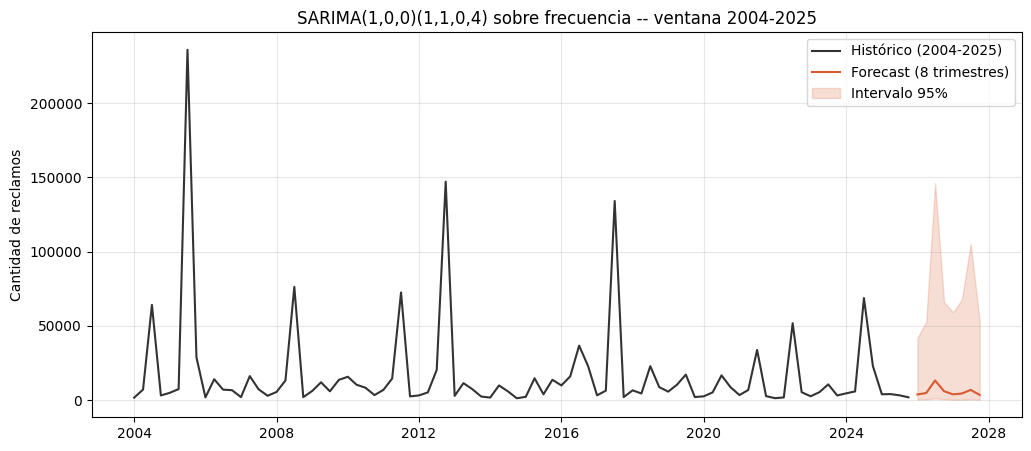

In [4]:
fit_freq = SARIMAX(freq_recent, order=(1,0,0), seasonal_order=(1,1,0,4),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

print(fit_freq.summary())

fc = fit_freq.get_forecast(steps=8)
mean_fc = np.exp(fc.predicted_mean)
ci = np.exp(fc.conf_int())

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(np.exp(freq_recent).index, np.exp(freq_recent).values, label="Histórico (2004-2025)", color="#333")
ax.plot(mean_fc.index, mean_fc.values, label="Forecast (8 trimestres)", color="#D85A30")
ax.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], color="#D85A30", alpha=0.2, label="Intervalo 95%")
ax.set_title("SARIMA(1,0,0)(1,1,0,4) sobre frecuencia -- ventana 2004-2025")
ax.set_ylabel("Cantidad de reclamos")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [5]:
fit_sev = SARIMAX(sev_recent, order=(1,0,1), seasonal_order=(1,1,1,4),
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(fit_sev.summary())

C:\Users\ramir\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\ramir\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                 avg_severity_real   No. Observations:                   88
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 4)   Log Likelihood                 -42.923
Date:                           Mon, 24 Aug 2026   AIC                             95.846
Time:                                   13:50:08   BIC                            107.630
Sample:                               01-01-2004   HQIC                           100.564
                                    - 10-01-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5079      0.606     -0.838      0.402      -1.696       0.680
ma.L1          0.5876      0.584      1.007

In [14]:
losses_full = df["total_paid_real"] / 1e6

threshold = np.percentile(losses_full, 90)
exceedances = losses_full[losses_full > threshold] - threshold

print(f"Umbral (percentil 90): ${threshold:,.0f}M")
print(f"Trimestres que superan el umbral: {len(exceedances)} de {len(losses_full)}")

shape, loc, scale = genpareto.fit(exceedances, floc=0)
print(f"Parámetros GPD -- forma (xi): {shape:.3f}, escala (sigma): {scale:.1f}")

def prob_loss_greater_than(x):
    if x <= threshold:
        return np.mean(losses_full > x)
    y = x - threshold
    return (len(exceedances)/len(losses_full)) * (1 + shape * y / scale) ** (-1/shape)

for x in [1000, 4000, 10000, 17000]:
    p = prob_loss_greater_than(x)
    print(f"P(pérdida trimestral > ${x:,}M) = {p:.4f}  (~1 en {1/(p*4):.1f} años)")

Umbral (percentil 90): $1,006M
Trimestres que superan el umbral: 20 de 192
Parámetros GPD -- forma (xi): 1.605, escala (sigma): 519.6
P(pérdida trimestral > $1,000M) = 0.1042  (~1 en 2.4 años)
P(pérdida trimestral > $4,000M) = 0.0244  (~1 en 10.2 años)
P(pérdida trimestral > $10,000M) = 0.0128  (~1 en 19.5 años)
P(pérdida trimestral > $17,000M) = 0.0091  (~1 en 27.6 años)


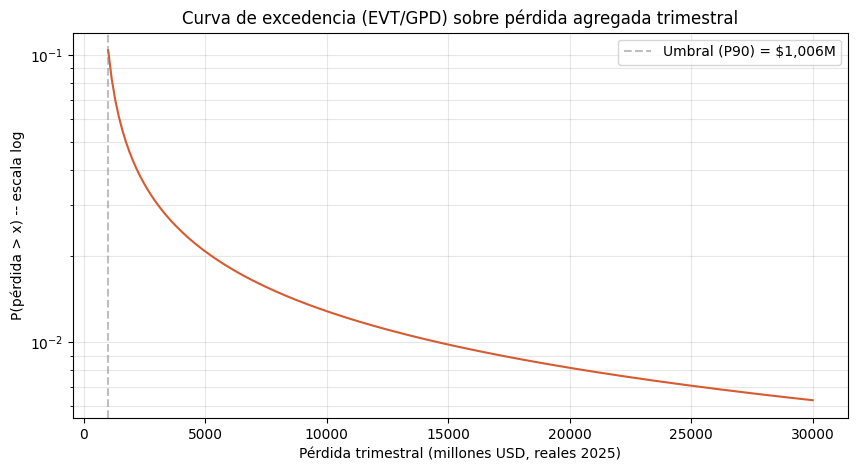

In [7]:
# Curva de excedencia completa -- visualizar la probabilidad de superar
# cualquier umbral, no solo los puntos específicos que ya calculamos
x_vals = np.linspace(threshold, 30000, 200)
y_vals = [prob_loss_greater_than(x) for x in x_vals]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(x_vals, y_vals, color="#D85A30")
ax.set_yscale("log")
ax.set_xlabel("Pérdida trimestral (millones USD, reales 2025)")
ax.set_ylabel("P(pérdida > x) -- escala log")
ax.set_title("Curva de excedencia (EVT/GPD) sobre pérdida agregada trimestral")
ax.grid(alpha=0.3, which="both")
ax.axvline(threshold, color="gray", linestyle="--", alpha=0.5, label=f"Umbral (P90) = ${threshold:,.0f}M")
ax.legend()
plt.show()

In [8]:
# Probabilidad de evento catastrófico, específica por trimestre del año
# (75% de los eventos históricos cayeron en Q3 -- no podemos usar un
# promedio parejo entre los 4 trimestres)
q_counts = df.index.quarter.value_counts().sort_index()
exceed_by_q = df.index[losses_full > threshold].quarter.value_counts().reindex([1,2,3,4], fill_value=0)
prob_cat_by_q = (exceed_by_q / q_counts).to_dict()
print("Probabilidad catastrófica por trimestre:", {k: round(v,3) for k,v in prob_cat_by_q.items()})

STEPS = 8
freq_fc = fit_freq.get_forecast(steps=STEPS)
sev_fc = fit_sev.get_forecast(steps=STEPS)
quarters_fc = freq_fc.predicted_mean.index

np.random.seed(42)
N_SIMS = 20000
rows = []
for i in range(STEPS):
    q = quarters_fc[i].quarter
    p_cat = prob_cat_by_q[q]

    log_freq = np.random.normal(freq_fc.predicted_mean.values[i], freq_fc.se_mean.values[i], N_SIMS)
    log_sev = np.random.normal(sev_fc.predicted_mean.values[i], sev_fc.se_mean.values[i], N_SIMS)
    baseline_loss = (np.exp(log_freq) * np.exp(log_sev)) / 1e6  # a millones, mismo escala que EVT

    is_cat = np.random.random(N_SIMS) < p_cat
    gpd_samples = threshold + genpareto.rvs(shape, loc=0, scale=scale, size=N_SIMS)
    total_loss = np.where(is_cat, np.maximum(baseline_loss, gpd_samples), baseline_loss)

    rows.append({
        "quarter": quarters_fc[i].date(), "prob_evento_catastrofico": round(p_cat, 3),
        "loss_p10_M": np.percentile(total_loss, 10),
        "loss_mediana_M": np.percentile(total_loss, 50),
        "loss_p90_M": np.percentile(total_loss, 90),
        "loss_p99_M": np.percentile(total_loss, 99),
    })

summary = pd.DataFrame(rows)

# CORRECCIÓN: redondear cada columna con su propia precisión, en vez de
# aplicar .round(0) a todo el DataFrame parejo (eso volvía 0 cualquier
# probabilidad menor a 0.5)
summary_display = summary.copy()
summary_display["prob_evento_catastrofico"] = summary_display["prob_evento_catastrofico"].round(3)
for col in ["loss_p10_M", "loss_mediana_M", "loss_p90_M", "loss_p99_M"]:
    summary_display[col] = summary_display[col].round(0)

print(summary_display.to_string(index=False))
summary.to_csv("nfip_final_combined_forecast.csv", index=False)

Probabilidad catastrófica por trimestre: {1: 0.0, 2: 0.062, 3: 0.312, 4: 0.042}
   quarter  prob_evento_catastrofico  loss_p10_M  loss_mediana_M  loss_p90_M  loss_p99_M
2026-01-01                     0.000        23.0           116.0       619.0      2526.0
2026-04-01                     0.062        41.0           227.0      1412.0      7755.0
2026-07-01                     0.312       199.0          1240.0      6300.0     75064.0
2026-10-01                     0.042        42.0           228.0      1354.0      6688.0
2027-01-01                     0.000        18.0           112.0       737.0      3266.0
2027-04-01                     0.062        32.0           217.0      1601.0      9990.0
2027-07-01                     0.312        85.0           942.0      5038.0     86485.0
2027-10-01                     0.042        20.0           133.0      1081.0      6112.0


In [15]:
# --- 1. Período de retorno que el modelo asigna al P99 ---
for x in [17000, 40000, 75000, 86000]:
    p = prob_loss_greater_than(x)
    print(f"P(pérdida > ${x:,}M) = {p:.5f}  (~1 en {1/(p*4):,.0f} años)")

# --- 2. Bootstrap del parámetro de forma (xi) ---
n_boot = 2000
xis = np.empty(n_boot)
rng = np.random.default_rng(42)   # semilla fija para que sea reproducible

for i in range(n_boot):
    # Remuestreo con reemplazo: tomamos 20 excedencias de las 20 originales,
    # permitiendo repetidos. Cada muestra simula "otro histórico posible".
    muestra = rng.choice(exceedances.values, size=len(exceedances), replace=True)
    xis[i] = genpareto.fit(muestra, floc=0)[0]

print(f"\nxi puntual: {shape:.3f}")
print(f"IC 95%: [{np.percentile(xis, 2.5):.3f}, {np.percentile(xis, 97.5):.3f}]")
print(f"Corridas con xi >= 1 (media infinita): {(xis >= 1).mean()*100:.1f}%")
print(f"Corridas con xi >= 0.5 (varianza infinita): {(xis >= 0.5).mean()*100:.1f}%")

P(pérdida > $17,000M) = 0.00906  (~1 en 28 años)
P(pérdida > $40,000M) = 0.00524  (~1 en 48 años)
P(pérdida > $75,000M) = 0.00352  (~1 en 71 años)
P(pérdida > $86,000M) = 0.00323  (~1 en 77 años)

xi puntual: 1.605
IC 95%: [0.259, 3.288]
Corridas con xi >= 1 (media infinita): 73.6%
Corridas con xi >= 0.5 (varianza infinita): 93.6%


In [9]:
df_full = pd.read_csv("nfip_quarterly_adjusted.csv")
print(df_full.columns.tolist())

['quarter', 'n_claims', 'avg_severity', 'total_paid', 'year', 'quarter_dt', 'deflator', 'avg_severity_real', 'total_paid_real']


In [10]:
# Ordenamos la serie de mayor a menor por pérdidas pagadas ajustadas
peores = df_full.sort_values("total_paid", ascending=False).head(10)

# Mostramos los 10 peores trimestres del histórico
print(peores[["quarter", "n_claims", "avg_severity", "total_paid"]].to_string(index=False))

# Guardamos el máximo histórico para usarlo como referencia
peor_trimestre = df_full["total_paid"].max()
peor_periodo   = df_full.loc[df_full["total_paid"].idxmax(), "quarter"]

print(f"\nPeor trimestre histórico: {peor_periodo} = ${peor_trimestre:,.0f}")

quarter  n_claims  avg_severity   total_paid
 2005Q3    235890  72080.626647 1.700310e+10
 2017Q3    134070  77468.096182 1.038615e+10
 2012Q4    147056  61117.665912 8.987719e+09
 2024Q3     68721 103630.803881 7.121612e+09
 2022Q3     51776  97051.246014 5.024925e+09
 2008Q3     76242  38940.090869 2.968870e+09
 2016Q3     36688  73694.881174 2.703718e+09
 2004Q3     64131  32405.740253 2.078213e+09
 2011Q3     72505  26533.419111 1.923806e+09
 2021Q3     33809  43744.855475 1.478970e+09

Peor trimestre histórico: 2005Q3 = $17,003,099,020


In [12]:
# Lista todas las variables en memoria que sean arrays grandes (candidatas a ser el Monte Carlo)
for nombre, valor in list(globals().items()):
    if nombre.startswith("_"):
        continue
    if isinstance(valor, np.ndarray) and valor.size > 1000:
        print(f"{nombre:30} shape={valor.shape}  min=${valor.min():,.0f}  max=${valor.max():,.0f}")
    elif isinstance(valor, dict) and len(valor) < 20:
        print(f"{nombre:30} dict con llaves: {list(valor.keys())}")

Out                            dict con llaves: []
prob_cat_by_q                  dict con llaves: [1, 2, 3, 4]
log_freq                       shape=(20000,)  min=$2  max=$14
log_sev                        shape=(20000,)  min=$9  max=$12
baseline_loss                  shape=(20000,)  min=$0  max=$31,209
is_cat                         shape=(20000,)  min=$0  max=$1
gpd_samples                    shape=(20000,)  min=$1,006  max=$34,503,831,560
total_loss                     shape=(20000,)  min=$0  max=$1,199,603


In [13]:
print(f"total_loss     → mediana ${np.median(total_loss):,.0f}")
print(f"                 P99     ${np.percentile(total_loss, 99):,.0f}")
print(f"                 máximo  ${total_loss.max():,.0f}")
print(f"\nis_cat: {is_cat.mean()*100:.1f}% de las corridas tuvieron evento catastrófico")
print(f"prob_cat_by_q: {prob_cat_by_q}")

total_loss     → mediana $133
                 P99     $6,112
                 máximo  $1,199,603

is_cat: 3.8% de las corridas tuvieron evento catastrófico
prob_cat_by_q: {1: 0.0, 2: 0.0625, 3: 0.3125, 4: 0.041666666666666664}


### Validación y cuantificación de incertidumbre

Anclaje empírico de la curva de excedencia contra el peor trimestre 
observado, y bootstrap del parámetro de forma para acotar la 
confiabilidad de los cuantiles extremos.

In [16]:
import json, numpy as np

validacion = {
    "peor_trimestre_historico": {"periodo": "2005Q3", "perdida_musd": 17003},
    "n_trimestres": int(len(losses_full)),
    "n_excedencias": int(len(exceedances)),
    "umbral_p90_musd": float(threshold),
    "xi_puntual": float(shape),
    "sigma": float(scale),
    "xi_ic95": [float(np.percentile(xis, 2.5)), float(np.percentile(xis, 97.5))],
    "pct_media_infinita": float((xis >= 1).mean()),
    "pct_varianza_infinita": float((xis >= 0.5).mean()),
    "periodos_retorno": {str(x): float(1/(prob_loss_greater_than(x)*4))
                         for x in [1000, 4000, 10000, 17000, 40000, 75000, 86000]},
}

with open("evt_validacion.json", "w", encoding="utf-8") as f:
    json.dump(validacion, f, indent=2, ensure_ascii=False)

np.save("bootstrap_xis.npy", xis)   # los 2,000 remuestreos crudos
print(json.dumps(validacion, indent=2, ensure_ascii=False))

{
  "peor_trimestre_historico": {
    "periodo": "2005Q3",
    "perdida_musd": 17003
  },
  "n_trimestres": 192,
  "n_excedencias": 20,
  "umbral_p90_musd": 1005.9682154974234,
  "xi_puntual": 1.60508105616535,
  "sigma": 519.5534904530338,
  "xi_ic95": [
    0.25890381095563053,
    3.287894134978295
  ],
  "pct_media_infinita": 0.7355,
  "pct_varianza_infinita": 0.936,
  "periodos_retorno": {
    "1000": 2.4,
    "4000": 10.230655592769006,
    "10000": 19.467474616401784,
    "17000": 27.600803615538418,
    "40000": 47.73880716948756,
    "75000": 70.98057541526796,
    "86000": 77.3548766706812
  }
}


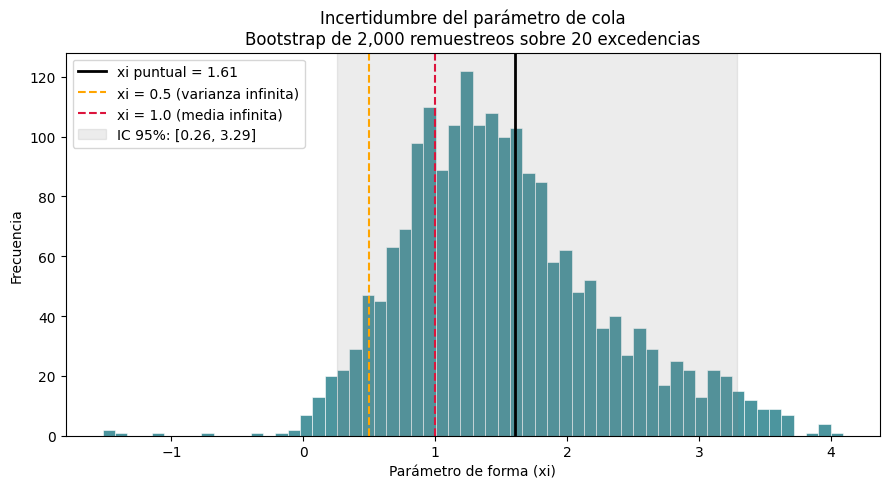

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(xis, bins=60, color="#4C959E", edgecolor="white", linewidth=0.4)

ax.axvline(shape, color="black", lw=2, label=f"xi puntual = {shape:.2f}")
ax.axvline(0.5, color="orange", ls="--", lw=1.5, label="xi = 0.5 (varianza infinita)")
ax.axvline(1.0, color="crimson", ls="--", lw=1.5, label="xi = 1.0 (media infinita)")

# Sombreamos el IC 95%
lo, hi = np.percentile(xis, [2.5, 97.5])
ax.axvspan(lo, hi, color="gray", alpha=0.15, label=f"IC 95%: [{lo:.2f}, {hi:.2f}]")

ax.set_xlabel("Parámetro de forma (xi)")
ax.set_ylabel("Frecuencia")
ax.set_title(f"Incertidumbre del parámetro de cola\nBootstrap de {len(xis):,} remuestreos sobre {len(exceedances)} excedencias")
ax.legend()
plt.tight_layout()
plt.savefig("bootstrap_xi.png", dpi=150)
plt.show()

In [18]:
print(df["total_paid_real"].max()/1e6, df_full["total_paid"].max()/1e6)

28025.077186112987 17003.09901972


In [19]:
# ¿Son el mismo número de filas?
print(df.shape, df_full.shape)

# Comparamos el mismo trimestre en ambas series
for col, d in [("total_paid_real", df), ("total_paid", df_full)]:
    top = d.nlargest(3, col)
    print(f"\n--- {col} ---")
    print(top[[c for c in ["quarter", col] if c in top.columns]].to_string(index=False))

# ¿Existe la columna nominal en alguna?
print("\nColumnas df:     ", df.columns.tolist())
print("Columnas df_full:", df_full.columns.tolist())

(192, 8) (194, 9)

--- total_paid_real ---
quarter  total_paid_real
 2005Q3     2.802508e+10
 2017Q3     1.364056e+10
 2012Q4     1.260081e+10

--- total_paid ---
quarter   total_paid
 2005Q3 1.700310e+10
 2017Q3 1.038615e+10
 2012Q4 8.987719e+09

Columnas df:      ['quarter', 'n_claims', 'avg_severity', 'total_paid', 'year', 'deflator', 'avg_severity_real', 'total_paid_real']
Columnas df_full: ['quarter', 'n_claims', 'avg_severity', 'total_paid', 'year', 'quarter_dt', 'deflator', 'avg_severity_real', 'total_paid_real']


In [20]:
peor_real = df["total_paid_real"].max() / 1e6   # en millones, como losses_full
print(f"Peor trimestre (real): ${peor_real:,.0f}M")

for x in [4000, 10000, peor_real, 75000, 86000]:
    p = prob_loss_greater_than(x)
    print(f"${x:>10,.0f}M → 1 en {1/(p*4):,.1f} años")

Peor trimestre (real): $28,025M
$     4,000M → 1 en 10.2 años
$    10,000M → 1 en 19.5 años
$    28,025M → 1 en 38.1 años
$    75,000M → 1 en 71.0 años
$    86,000M → 1 en 77.4 años
